In [1]:
import os
import requests

import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt

from nuscenes.nuscenes import NuScenes
from data.nuscenes_data import NuscenesData

from bevfusion.bevfusion import BEVFusion

In [2]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = BEVFusion().to(device)
model.eval()

BEVFusion(
  (lidar_line): LidarLine(
    (pts_voxel_layer): Voxelization(voxel_size=[0.075, 0.075, 0.2], point_cloud_range=[-54.0, -54.0, -5.0, 54.0, 54.0, 3.0], max_num_points=10, max_voxels=(120000, 160000), deterministic=True)
    (pts_middle_encoder): BEVFusionSparseEncoder(
      (conv_input): SparseSequential(
        (0): SubMConv3d(5, 16, kernel_size=[3, 3, 3], stride=[1, 1, 1], padding=[1, 1, 1], dilation=[1, 1, 1], output_padding=[0, 0, 0], bias=False, algo=ConvAlgo.MaskImplicitGemm)
        (1): BatchNorm1d(16, eps=0.001, momentum=0.01, affine=True, track_running_stats=True)
        (2): ReLU(inplace=True)
      )
      (encoder_layers): ModuleDict(
        (encoder_layer1): SparseSequential(
          (0): SparseBasicBlock(
            (conv1): SubMConv3d(16, 16, kernel_size=[3, 3, 3], stride=[1, 1, 1], padding=[1, 1, 1], dilation=[1, 1, 1], output_padding=[0, 0, 0], bias=False, algo=ConvAlgo.MaskImplicitGemm)
            (bn1): BatchNorm1d(16, eps=0.001, momentum=0.01, af

In [3]:
os.makedirs("checkpoints", exist_ok=True)
# https://download.openmmlab.com/mmdetection3d/v1.1.0_models/bevfusion/bevfusion_lidar-cam_voxel0075_second_secfpn_8xb4-cyclic-20e_nus-3d-5239b1af.pth
official_ckpt_path = "checkpoints/bevfusion_lidar-cam_voxel0075_second_secfpn_8xb4-cyclic-20e_nus-3d-5239b1af.pth" # Downloaded from mmdetection3d BEVFusion model zoo
if not os.path.exists(official_ckpt_path):
    url = "https://download.openmmlab.com/mmdetection3d/v1.1.0_models/bevfusion/bevfusion_lidar-cam_voxel0075_second_secfpn_8xb4-cyclic-20e_nus-3d-5239b1af.pth"
    print(f"Downloading official checkpoint from {url}...")
    response = requests.get(url)
    with open(official_ckpt_path, 'wb') as f:
        f.write(response.content)
    print("Download completed.")
output_ckpt_path = "checkpoints/bevfusion_pytorch.pth"
if not os.path.exists(output_ckpt_path):
    model.convert_and_save_checkpoint(model, official_ckpt_path=official_ckpt_path, output_ckpt_path=output_ckpt_path)

In [4]:
ckpt = torch.load(output_ckpt_path, map_location=device)
model.load_state_dict(ckpt)

<All keys matched successfully>

In [5]:
def nusc_to_mm_coords(points):
    """
    Convert points from NuScenes LiDAR convention to MM convention when enabled.
    """
    new_points = points.clone()
    old_x = new_points[..., 0].clone()
    old_y = new_points[..., 1].clone()
    # NuScenes Y (Forward) -> MM X (Forward)
    new_points[..., 0] = old_y
    # NuScenes X (Right) -> MM -Y (Left is positive)
    new_points[..., 1] = -old_x
    return new_points

In [6]:
def visualize_six_images(imgs, cam_names=None):
    """Display six camera images from [1, 6, 3, H, W] or [6, 3, H, W]."""
    if imgs.dim() == 5:
        cam_imgs = imgs[0]
    elif imgs.dim() == 4:
        cam_imgs = imgs
    else:
        raise ValueError(f"Expected imgs shape [1, 6, 3, H, W] or [6, 3, H, W], got {tuple(imgs.shape)}")

    if cam_imgs.shape[0] != 6:
        raise ValueError(f"Expected 6 cameras, got {cam_imgs.shape[0]}")

    if cam_names is None:
        cam_names = ["CAM_BACK", "CAM_BACK_LEFT", "CAM_FRONT_LEFT", "CAM_FRONT", "CAM_FRONT_RIGHT", "CAM_BACK_RIGHT"]

    fig, axes = plt.subplots(2, 3, figsize=(15, 8))
    axes = axes.flatten()

    for i in range(6):
        img = cam_imgs[i].detach().cpu().permute(1, 2, 0).numpy()
        axes[i].imshow(img)
        axes[i].set_title(f"{i}: {cam_names[i]}")
        axes[i].axis('off')

    fig.tight_layout()
    plt.show()

In [ ]:
DATA_ROOT = "/home/ximeng/Dataset/nuscenes_full_v1_0" # Change this to your actual NuScenes dataset path
nusc = NuScenes(version="v1.0-trainval", dataroot=DATA_ROOT, verbose=True)
dataset = NuscenesData(nusc, is_train=1, pre_frames=0, future_frames=0)

Loading NuScenes tables for version v1.0-trainval...
23 category,
8 attribute,
4 visibility,
64386 instance,
12 sensor,
10200 calibrated_sensor,
2631083 ego_pose,
68 log,
850 scene,
34149 sample,
2631083 sample_data,
1166187 sample_annotation,
4 map,
Done loading in 19.849 seconds.
Reverse indexing ...
Done reverse indexing in 4.4 seconds.


In [78]:
SAMPLE_IDX = 0 # You can change this index to visualize different samples

data = dataset[SAMPLE_IDX]
fused_pc = data['fused_pc'][-1]  # [N, 5] (X, Y, Z, Intensity, Time_Lag)
points = fused_pc.unsqueeze(0).to(device)  # [1, N, 5]
points_mm = nusc_to_mm_coords(points)

aug_transform = torch.tensor([
    [0.44,  0.0,  0.0,    0.0],
    [ 0.0, 0.44,  0.0, -140.0],
    [ 0.0,  0.0,  1.0,    0.0],
    [ 0.0,  0.0,  0.0,    1.0]
], dtype=torch.float32, device=device)

raw_imgs = data['raw_images'][-1]
imgs_resized = F.interpolate(
    raw_imgs, 
    size=(396, 704), 
    mode='bilinear', 
    align_corners=False
)
# 396 - 140 = 256
imgs_cropped = imgs_resized[:, :, 140:, :]
imgs = imgs_cropped.view(1, 6, 3, 256, 704).to(device)

mats_dict = {
    'camera_intrinsics': data['cam_intrinsic'][-1].unsqueeze(0).to(device),  # [B, num_cams, 4, 4]
    'camera2lidar': data['camera2lidar'][-1].unsqueeze(0).to(device),  # [B, num_cams, 4, 4]
    'lidar2image': data['lidar2image'][-1].unsqueeze(0).to(device),  # [B, num_cams, 4, 4]
    'img_aug_matrix': aug_transform.view(1, 1, 4, 4).repeat(1, 6, 1, 1),
    'lidar_aug_matrix': torch.eye(4, device=device).view(1, 4, 4).repeat(1, 1, 1),  # Identity (no augmentation)
}

R_trans = torch.tensor([
    [0,  1,  0,  0],
    [-1, 0,  0,  0],
    [0,  0,  1,  0],
    [0,  0,  0,  1]
], dtype=torch.float32, device=device)
# Camera -> Lidar_Nusc -> Lidar_MM
c2l_mm = R_trans @ mats_dict['camera2lidar']
l2i_mm = mats_dict['lidar2image'] @ torch.inverse(R_trans)
mats_dict_mm = {
    'camera_intrinsics': mats_dict['camera_intrinsics'],
    'camera2lidar': c2l_mm,
    'lidar2image': l2i_mm,
    'img_aug_matrix': mats_dict['img_aug_matrix'],
    'lidar_aug_matrix': mats_dict['lidar_aug_matrix'],
}

In [79]:
# 1. Move all tensors to the CPU to prevent device binding issues during loading
demo_data = {
    'imgs': imgs.cpu(),
    'points_mm': points_mm.cpu(),
    # mats_dict_mm is a dictionary, so we iterate through its values to move them to the CPU
    'mats_dict_mm': {k: v.cpu() for k, v in mats_dict_mm.items()}
}

# 2. Save as a single file
save_path = f"data/nuscenes_demo_{SAMPLE_IDX}.pt"
# torch.save(demo_data, save_path)
# print(f"Demo data successfully packaged and saved to: {save_path}")

In [80]:
def visualize_bev_features(bev_feat, title="BEV Feature Map"):
    # bev_feat: [1, 256, 180, 180]
    feat_2d, _ = bev_feat[0].max(dim=0) # [180, 180]
    plt.figure(figsize=(6, 6))
    plt.imshow(feat_2d.detach().cpu().numpy(), origin='lower', cmap='viridis')
    plt.colorbar(label='Feature Intensity')
    plt.xlabel("Physical Y (Left/Right)")
    plt.ylabel("Physical X (Front/Back)")
    plt.title(title)
    plt.axis('on')
    plt.show()

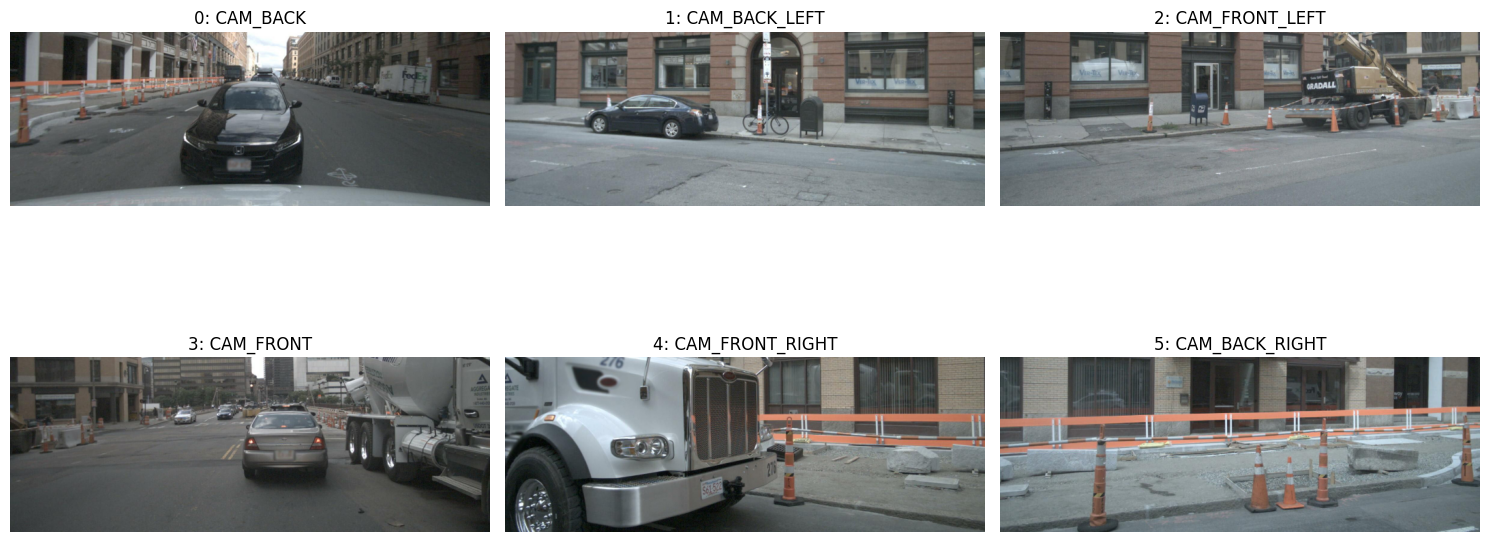

In [81]:
visualize_six_images(imgs)

dict_keys(['lidar_feats', 'cam_feats', 'bev_feats', 'tgt', 'bbox_preds', 'classes', 'scores'])


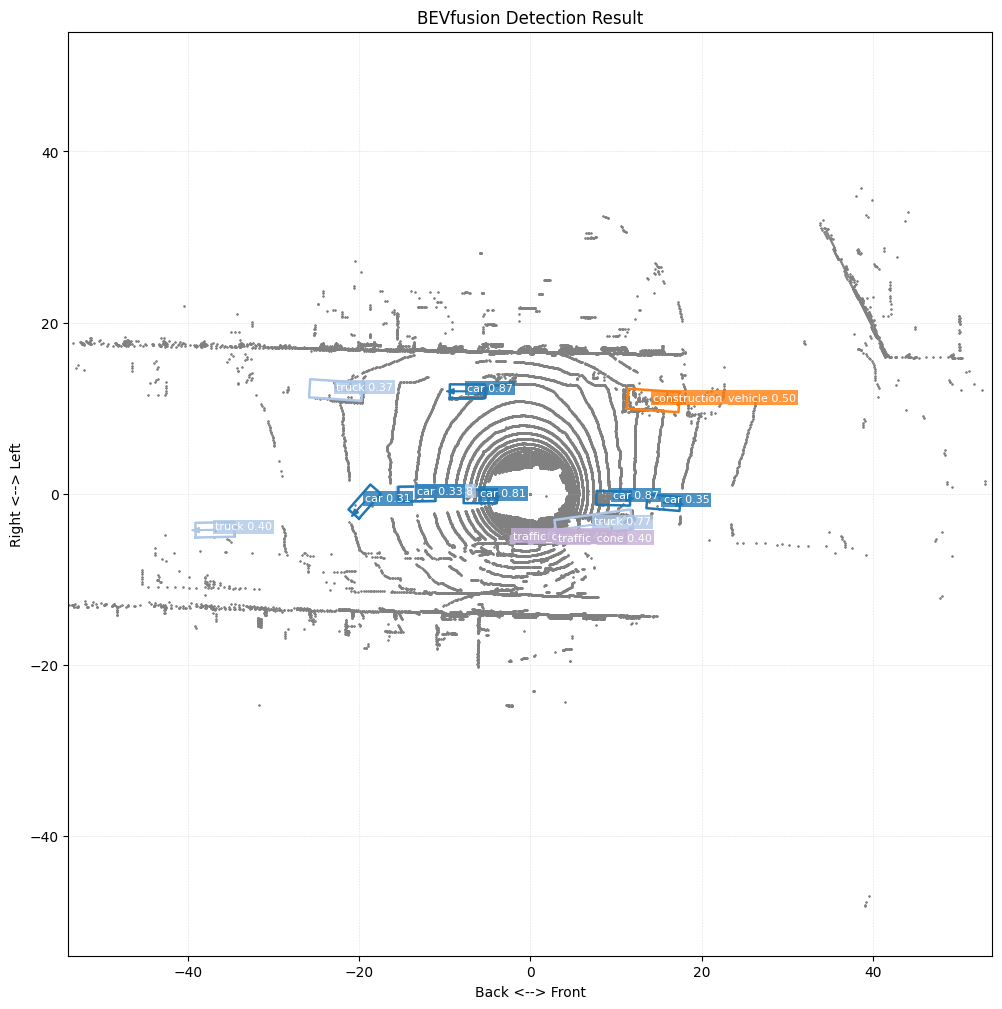

In [82]:
dict_results = model(imgs, points_mm, mats_dict_mm)
print(dict_results.keys())
# visualize_bev_features(dict_results['cam_feats'], title="Camera BEV Feature Map")
# visualize_bev_features(dict_results['lidar_feats'], title="Lidar BEV Feature Map")
# visualize_bev_features(dict_results['bev_feats'], title="Fused BEV Feature Map")
decoded_boxes_from_model = model.decode_bbox(dict_results['bbox_preds'], score_threshold=0.2)
model.visualize_results(
    points_mm[0, :, :3].cpu().numpy(),
    decoded_boxes_from_model,
    score_thr=0.3,
    point_size=0.2,
    point_alpha=0.35,
    point_color='gray'
)